In [ ]:
# 05 — Feature Engineering and Leakage Policy

Builds the modelling dataset for SQ2 and SQ3.

A feature is admissible only if its value is determined before the outcome
of the shot is known. Two variables fail this test:

- `depth` of the current shot: a ball that lands out has no recorded depth,
  so missingness alone identifies errors.
- `error_type`: this is the outcome, not a predictor.

`rally_length` and `point_outcome` are also excluded, since both encode
which shot ended the point.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")

CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "data").exists() else CWD.parent
PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"

shots = pd.read_parquet(PROCESSED / "shots_eda.parquet")
print("Shots:", shots.shape)

# Evidence for the leakage policy: missingness is not random with respect
# to the target, so a model could exploit it instead of learning tactics.
leak_check = shots.groupby("shot_outcome")[["direction", "depth"]].apply(
    lambda g: g.isna().mean())
print("\nShare of missing values by shot outcome:")
print(leak_check.round(3))

Shots: (5313675, 17)

Share of missing values by shot outcome:
                direction  depth
shot_outcome                    
forced_error        0.140  0.956
in_play             0.010  0.573
unforced_error      0.024  0.953
winner              0.009  0.669


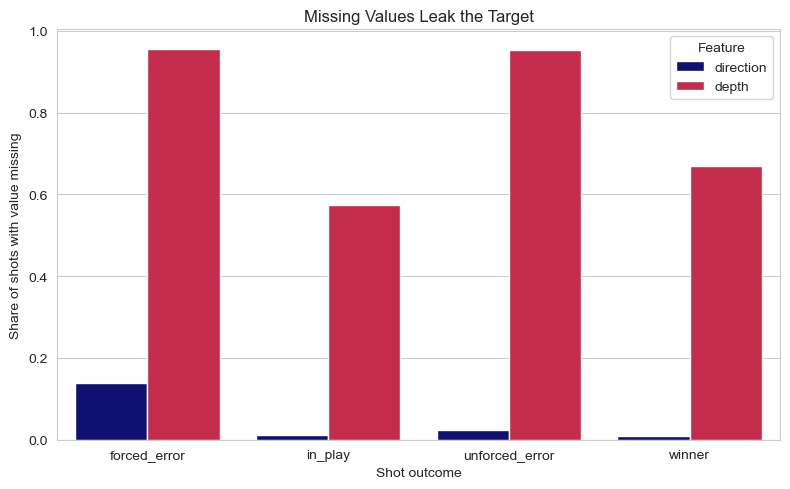

In [2]:
# Visual version of the same evidence, for the report.
plot_data = leak_check.reset_index().melt(id_vars="shot_outcome",
                                          var_name="feature",
                                          value_name="missing_share")

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_data, x="shot_outcome", y="missing_share", hue="feature",
            palette=["navy", "crimson"])
plt.title("Missing Values Leak the Target")
plt.xlabel("Shot outcome")
plt.ylabel("Share of shots with value missing")
plt.legend(title="Feature")
plt.tight_layout()
plt.savefig(FIGURES / "leakage_missingness.png", dpi=150)
plt.show()

In [3]:
# The incoming ball matters: a player facing a deep cross-court ball is in a
# different situation from one facing a short middle ball. These lagged
# features describe that situation and are known before the shot is played.
shots = shots.sort_values(["match_id", "Pt", "shot_number"])

group = shots.groupby(["match_id", "Pt"], observed=True)
shots["prev_shot_type"] = group["shot_type"].shift(1)
shots["prev_direction"] = group["direction"].shift(1)
shots["prev_depth"] = group["depth"].shift(1)
shots["prev_approach"] = group["is_approach"].shift(1)

# Shot 2 (the return) has no preceding rally shot, so these are empty there.
print("Lag features created. Missing prev_shot_type:",
      shots["prev_shot_type"].isna().mean().round(3))

Lag features created. Missing prev_shot_type: 0.231


In [4]:
# Target 1: four-class shot outcome (already built in notebook 04).
shots["target_outcome"] = shots["shot_outcome"]

# Target 2: binary simplification. Only decisive shots are kept, so the
# question becomes "given that this shot ended the point, did it end it well?"
decisive = shots["shot_outcome"] != "in_play"
shots["target_binary"] = np.where(
    shots["shot_outcome"].isin(["winner", "forced_error"]), "success",
    np.where(shots["shot_outcome"] == "unforced_error", "failure", None))

# Target 3: aggressiveness index. This is an ENGINEERED variable, not a
# label present in the data. A shot is aggressive if it took the point,
# either outright or by forcing the opponent into an error.
shots["aggressiveness"] = np.where(
    shots["shot_outcome"].isin(["winner", "forced_error"]), 1, 0)

print(shots["target_outcome"].value_counts(normalize=True).round(3))
print("\nDecisive shots available for the binary target:", decisive.sum())

target_outcome
in_play           0.769
unforced_error    0.087
forced_error      0.081
winner            0.063
Name: proportion, dtype: float64

Decisive shots available for the binary target: 1227322


In [5]:
# Shots with no recorded direction are dropped. Direction is the central
# tactical variable, and its missingness is itself informative about the
# outcome, so keeping these rows would reintroduce leakage.
before = len(shots)
model_data = shots.dropna(subset=["direction"]).copy()

print(f"Dropped {before - len(model_data):,} shots "
      f"({100 * (before - len(model_data)) / before:.1f}%) with no direction.")
print("\nClass balance after dropping:")
print(model_data["target_outcome"].value_counts(normalize=True).round(3))

Dropped 116,876 shots (2.2%) with no direction.

Class balance after dropping:
target_outcome
in_play           0.778
unforced_error    0.087
forced_error      0.071
winner            0.064
Name: proportion, dtype: float64


In [6]:
# Everything here is either a choice the player made or context that existed
# before the shot was struck. Nothing describes what happened afterwards.
FEATURES = [
    "shot_number",        # how deep into the rally we are
    "shot_type",          # which stroke was chosen
    "direction",          # where it was aimed
    "direction_pattern",  # cross-court / down-the-line / middle
    "to_opponent_wing",   # forehand or backhand side, handedness-corrected
    "is_approach",        # did the player move forward
    "prev_shot_type",     # what they were responding to
    "prev_direction",
    "prev_depth",         # depth of the incoming ball
    "prev_approach",
    "is_serving",         # server or returner
    "serve_direction",    # how the point started
    "is_second_serve",
    "pressure_context",
    "Surface",
    "gender",
]

EXCLUDED = ["depth", "error_type", "rally_length", "point_outcome",
            "point_winner", "shot_outcome"]

print(f"{len(FEATURES)} features selected, {len(EXCLUDED)} excluded for leakage.")

16 features selected, 6 excluded for leakage.


In [7]:
# Some features live in the points table and must be joined onto the shots.
points = pd.read_parquet(PROCESSED / "points_eda.parquet")

point_cols = ["match_id", "Pt", "server", "serve_direction", "is_second_serve",
              "pressure_context", "Surface"]
model_data = model_data.merge(points[point_cols], on=["match_id", "Pt"],
                              how="left", suffixes=("", "_pt"))

# Server and returner face different situations, so the model needs to know
# which role the player hitting this shot is in.
model_data["is_serving"] = (model_data["hitter"] == model_data["server"])

missing_features = [c for c in FEATURES if c not in model_data.columns]
print("Missing feature columns:", missing_features)
print("Rows:", len(model_data))

Missing feature columns: []
Rows: 5207197


In [8]:
keep = FEATURES + ["target_outcome", "target_binary", "aggressiveness",
                   "match_id", "Pt", "shot_number"]
keep = [c for c in dict.fromkeys(keep) if c in model_data.columns]

model_data[keep].to_parquet(PROCESSED / "model_data.parquet", index=False)
print("Saved model dataset:", model_data[keep].shape)

Saved model dataset: (5207197, 21)
